In [5]:
%matplotlib widget
import ipywidgets as widgets

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from src.data.data_loader import load_pupil_data
from src.utils.utilities import detect_and_interpolate_sudden_changes, normalize_series, detect_sudden_change_events, moving_average, normalize_mean_std

In [6]:
# Path to your data folder
path = "data/test/2023.05.07/cycle 6"

# Load raw pupil DataFrame
pupil_data = load_pupil_data(path)

# Set your threshold (adjust this as needed)
threshold_to_exclude_from_min_max = 1.0

# Normalize & interpolate
pupil_data_normalized   = normalize_mean_std(pupil_data)
interpolated_pupil_data = detect_and_interpolate_sudden_changes(
    pupil_data_normalized, 0.001, 1
)

# Compute sampling rate from the raw time column
pupil_sampling_rate = int(round(1 / np.mean(np.diff(pupil_data['time'].values))))

# Process the pupil series
pupil_size_normalized       = normalize_series(
    pupil_data['pupil_size'].values,
    threshold_to_exclude_from_min_max
)
smoothed_pupil_size         = moving_average(
    interpolated_pupil_data['pupil_size'].values,
    pupil_sampling_rate
)
normalized_smoothed_pupil_size = normalize_series(
    smoothed_pupil_size,
    threshold_to_exclude_from_min_max
)

# Align the time vector to the smoothed data
time_vals = interpolated_pupil_data['time'].values
half_win  = pupil_sampling_rate // 2
smoothed_time_series = time_vals[half_win : -half_win][: len(normalized_smoothed_pupil_size)]

print(f"Loaded {len(normalized_smoothed_pupil_size)} samples, sampling rate ~{pupil_sampling_rate} Hz")


Normalizing series: Maximum value is 1.6726551281853157
Normalizing series: Minimum value (at 1.0th percentile) is -1.601795296913585
Normalizing series: Maximum value is 1.5914288674267287
Normalizing series: Minimum value (at 1.0th percentile) is -1.6015461480789182
Loaded 34562 samples, sampling rate ~40 Hz


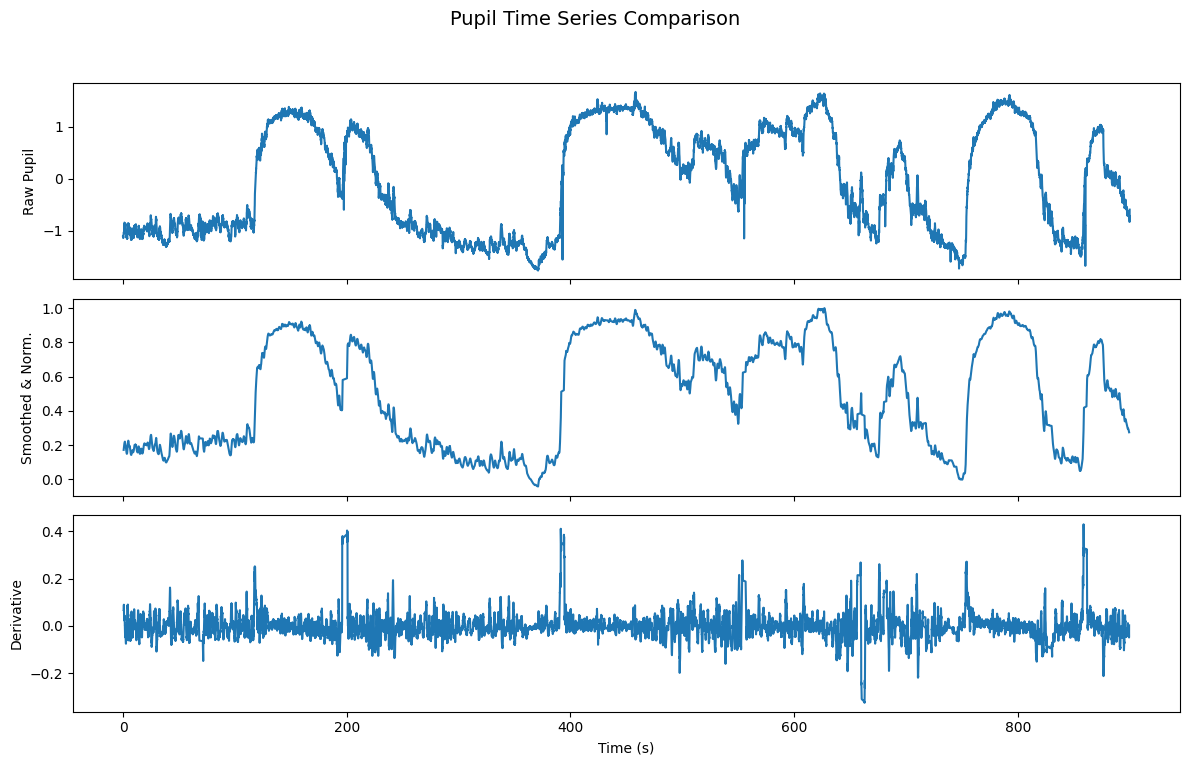

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- Your three (time, series) pairs ---
# Replace these with your real variables:
t1, s1 = pupil_data['time'].values, pupil_data['pupil_size'].values
t2, s2 = smoothed_time_series, normalized_smoothed_pupil_size
t3, s3 = smoothed_time_series, np.gradient(normalized_smoothed_pupil_size, 1/pupil_sampling_rate)

# --- Helper to align and crop them ---
def align_and_crop(t, s):
    # Make sure they’re numpy arrays
    t = np.asarray(t)
    s = np.asarray(s)
    n = min(t.shape[0], s.shape[0])
    return t[:n], s[:n]

t1c, s1c = align_and_crop(t1, s1)
t2c, s2c = align_and_crop(t2, s2)
t3c, s3c = align_and_crop(t3, s3)

# --- Plot 3×1 vertically stacked, shared x-axis ---
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Raw pupil
axs[0].plot(t1c, s1c)
axs[0].set_ylabel('Raw Pupil')

# Smoothed & normalized
axs[1].plot(t2c, s2c)
axs[1].set_ylabel('Smoothed & Norm.')

# Derivative (or your third series)
axs[2].plot(t3c, s3c)
axs[2].set_ylabel('Derivative')
axs[2].set_xlabel('Time (s)')

fig.suptitle('Pupil Time Series Comparison', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from src.utils.utilities import detect_sudden_change_events

def plot_detected_events_interactive(pupil_diameter, pupil_times, pupil_sampling_rate):
    pupil_diameter = np.asarray(pupil_diameter).ravel()
    pupil_times    = np.asarray(pupil_times).ravel()

    def _plot(ws, pev, ew, thr, st):
        ws_s, pev_s, ew_s, st_s = [int(x*pupil_sampling_rate) for x in (ws, pev, ew, st)]
        padding = 5

        events, indices = detect_sudden_change_events(
            pupil_diameter, padding, pev_s, ew_s, thr, st_s
        )

        # Build full‑length mask
        event_or_not = np.zeros_like(pupil_diameter)
        for win_idx, code in enumerate(indices):
            start = st_s * win_idx
            end   = start + pev_s + ew_s
            if code == 1:
                event_or_not[start:end] = 1
            elif code == 2:
                event_or_not[start:end] = -1

        # Smooth
        if ws_s > 1:
            kernel = np.ones(ws_s) / ws_s
            smooth = np.convolve(pupil_diameter, kernel, mode='same')
        else:
            smooth = pupil_diameter

        # Plot
        plt.figure(figsize=(10, 4))
        plt.plot(pupil_times, pupil_diameter, label='Raw')
        plt.plot(pupil_times, smooth,      label=f'Smooth {ws}s')
        plt.fill_between(pupil_times,
                         pupil_diameter.min(), pupil_diameter.max(),
                         where=(event_or_not > 0),
                         alpha=0.3, label='+ Event')
        plt.fill_between(pupil_times,
                         pupil_diameter.min(), pupil_diameter.max(),
                         where=(event_or_not < 0),
                         alpha=0.3, label='– Event')

        ax = plt.gca()
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Pupil Diameter')

        # Compact legend outside plot
        ax.legend(
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0.,
            ncol=2,
            fontsize='small',
            frameon=False
        )

        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()

    interact(
        _plot,
        ws = FloatSlider(value=1.0, min=0.0,  max=60.0, step=1.0, description='Smooth (s)'),
        pev= FloatSlider(value=5.0, min=1.0,  max=20.0, step=0.5, description='Baseline (s)'),
        ew = FloatSlider(value=5.0, min=1.0,  max=20.0, step=0.5, description='Event (s)'),
        thr= FloatSlider(value=3.0, min=1.0,  max=10.0, step=0.5, description='Threshold'),
        st = FloatSlider(value=0.5, min=0.1,  max=10.0, step=0.1, description='Step (s)')
    )


In [27]:
plot_detected_events_interactive(pupil_data_normalized['pupil_size'].values, pupil_data['time'].values, pupil_sampling_rate)

interactive(children=(FloatSlider(value=1.0, description='Smooth (s)', max=60.0, step=1.0), FloatSlider(value=…